In [26]:
import pandas as pd
import sqlite3

In [27]:
try:
  connect = sqlite3.connect('data/checking-logs.sqlite')
  print('OK. Connected to sqlite')

except sqlite3.Error as error:
  print('Error with connection:', error)

OK. Connected to sqlite


In [28]:
query = '''
SELECT uid, timestamp
FROM checker
WHERE uid LIKE 'user_%'
'''
commits = pd.io.sql.read_sql(query, connect, parse_dates=['timestamp'])
commits['timestamp'] = commits['timestamp'].astype('datetime64[us]')
commits

,uid,timestamp
0,user_4,2020-04-17 05:19:02.744528
1,user_4,2020-04-17 05:22:35.249331
2,user_4,2020-04-17 05:22:45.549397
3,user_4,2020-04-17 05:34:14.691200
4,user_4,2020-04-17 05:34:24.422370
...,...,...
3202,user_1,2020-05-21 20:19:06.872761
3203,user_1,2020-05-21 20:22:41.785725
3204,user_1,2020-05-21 20:22:41.877806
3205,user_1,2020-05-21 20:37:00.129678


In [29]:
commits['hh.mm'] = commits['timestamp'].dt.strftime('%H.%M')
commits['hh.mm'] = commits['hh.mm'].astype('float')
commits['day'] = commits['timestamp'].dt.day_name()
commits['timestamp'] = commits['timestamp'].dt.date
commits

,uid,timestamp,hh.mm,day
0,user_4,2020-04-17,5.19,Friday
1,user_4,2020-04-17,5.22,Friday
2,user_4,2020-04-17,5.22,Friday
3,user_4,2020-04-17,5.34,Friday
4,user_4,2020-04-17,5.34,Friday
...,...,...,...,...
3202,user_1,2020-05-21,20.19,Thursday
3203,user_1,2020-05-21,20.22,Thursday
3204,user_1,2020-05-21,20.22,Thursday
3205,user_1,2020-05-21,20.37,Thursday


In [30]:
commits.dtypes

uid              str
timestamp     object
hh.mm        float64
day              str
dtype: object

In [31]:
bins = [0,0.59, 1.59, 2.59, 3.59, 4.59, 5.59, 6.59, 7.59, 
    8.59, 9.59, 10.59, 11.59, 12.59, 13.59, 14.59, 
    15.59, 16.59, 17.59, 18.59, 19.59, 20.59, 21.59, 22.59, 23.59
]
labels = ['0-1', '1-2', '2-3', '3-4', '4-5', '5-6', '6-7', '7-8', 
    '8-9', '9-10', '10-11', '11-12', '12-13', '13-14', '14-15', 
    '15-16', '16-17', '17-18', '18-19', '19-20', '20-21', '21-22', 
    '22-23', '23-24'
]
commits['range_time']=pd.cut(commits['hh.mm'],bins = bins,labels = labels)
commits

,uid,timestamp,hh.mm,day,range_time
0,user_4,2020-04-17,5.19,Friday,5-6
1,user_4,2020-04-17,5.22,Friday,5-6
2,user_4,2020-04-17,5.22,Friday,5-6
3,user_4,2020-04-17,5.34,Friday,5-6
4,user_4,2020-04-17,5.34,Friday,5-6
...,...,...,...,...,...
3202,user_1,2020-05-21,20.19,Thursday,20-21
3203,user_1,2020-05-21,20.22,Thursday,20-21
3204,user_1,2020-05-21,20.22,Thursday,20-21
3205,user_1,2020-05-21,20.37,Thursday,20-21


In [33]:
result = commits.groupby(['day','range_time']).agg({'uid':'count'})
result

uid
day       range_time     
Friday    5-6          13
          6-7           1
          10-11        12
          11-12        18
          12-13         2
...                   ...
Wednesday 19-20        26
          20-21        31
          21-22        79
          22-23        18
          23-24        11

[119 rows x 1 columns]

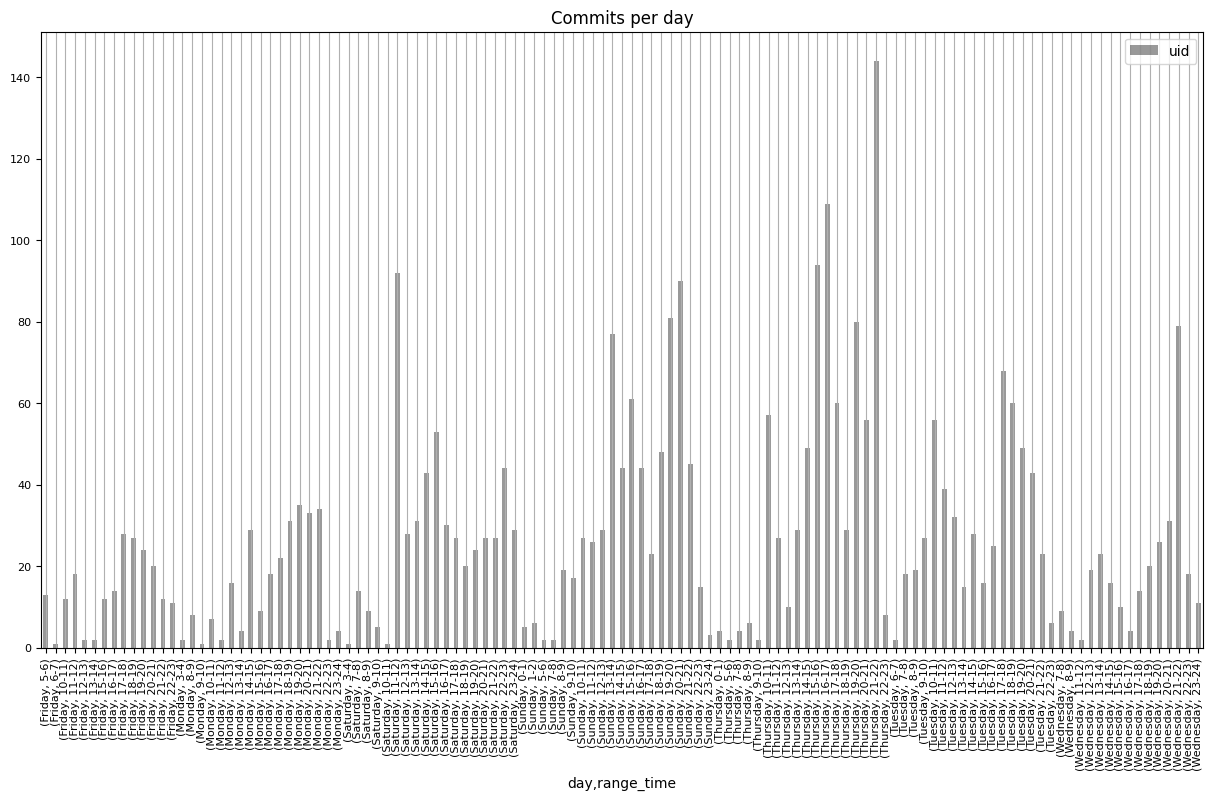

In [36]:
plt = result.plot.bar(figsize=(15,8),
    fontsize=8,
    title='Commits per day',
    rot=90,
    alpha=0.4,
    stacked=True,
    color=('black','red'))
plt.grid(axis='x')

In [28]:
connect.close()